In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# first article isn't publically available

In [4]:
data = load_breast_cancer()
X = data.data
y = data.target


feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)

In [5]:
def calculate_f_score(X, y):
  _, n_features = X.shape
  
  positive_indices = np.where(y == 1)[0]
  negative_indices = np.where(y == 0)[0]
  
  f_scores = []
  
  for i in range(n_features):
    mean_total = np.mean(X[:, i])
    mean_positive = np.mean(X[positive_indices, i])
    mean_negative = np.mean(X[negative_indices, i])
    
    numerator = (mean_positive - mean_total)**2 + (mean_negative - mean_total)**2
    
    var_positive = np.var(X[positive_indices, i])
    var_negative = np.var(X[negative_indices, i])
    
    denominator = var_positive + var_negative
    
    if denominator == 0:
      f_score = 0
    else:
      f_score = numerator / denominator
        
    f_scores.append(f_score)
  
  return np.array(f_scores)

f_scores = calculate_f_score(X, y)
f_scores

array([1.12489640e+00, 2.40621596e-01, 1.20511755e+00, 9.26819692e-01,
       1.70817161e-01, 5.59068773e-01, 9.36394774e-01, 1.44559797e+00,
       1.35858057e-01, 1.82271539e-04, 4.28915692e-01, 8.24636786e-05,
       4.01557404e-01, 3.69777368e-01, 5.21412026e-03, 1.03797271e-01,
       8.63288394e-02, 2.29534934e-01, 4.41556186e-05, 7.58731193e-03,
       1.44395087e+00, 3.01389083e-01, 1.50436476e+00, 1.03751870e+00,
       2.40517711e-01, 5.26187672e-01, 8.21138750e-01, 1.81320421e+00,
       2.06915411e-01, 1.19264782e-01])

In [6]:
def reproduce_table_2(X, y):
  splits = [0.5, 0.7, 0.8]
  
  table_2_data = []
  
  for split in splits:
    X_train, _, y_train, _ = train_test_split(X, y, train_size=split, random_state=42, stratify=y)
    
    f_scores_split = calculate_f_score(X_train, y_train)
    
    table_2_data.append(f_scores_split)
  
  table_2_df = pd.DataFrame({
    'Feature_no': range(1, len(feature_names) + 1),
    '50-50%_split': table_2_data[0],
    '70-30%_split': table_2_data[1], 
    '80-20%_split': table_2_data[2]
  })
  
  return table_2_df

table_2 = reproduce_table_2(X, y)
print("Table 2: Feature Importance with F-score")
table_2.head(9)

Table 2: Feature Importance with F-score


,Feature_no,50-50%_split,70-30%_split,80-20%_split
0,1,1.159276,1.202172,1.139488
1,2,0.220950,0.212035,0.230859
2,3,1.262356,1.291617,1.222339
3,4,1.026849,1.051493,0.952983
4,5,0.214557,0.197968,0.206071
5,6,0.618255,0.598385,0.594162
6,7,1.065281,0.940064,0.920910
7,8,1.645280,1.525537,1.466863
8,9,0.117568,0.145427,0.161171


In [7]:
def reproduce_table_3(f_scores, feature_names, top_k=9):
  sorted_indices = np.argsort(f_scores)[::-1]
  models = []
  
  for k in range(1, top_k + 1):
    selected_indices = sorted_indices[:k]
    selected_features = [feature_names[i] for i in selected_indices]
    
    models.append({
      'Model #': f'#{k}',
      'No. of selected features': k,
      'Features': ', '.join(selected_features)
    })
  
  return pd.DataFrame(models)

table_3 = reproduce_table_3(f_scores, feature_names)
print("Table 3: Feature Subsets based on F-score")
table_3

Table 3: Feature Subsets based on F-score


,Model #,No. of selected features,Features
0,#1,1,worst concave points
1,#2,2,"worst concave points, worst perimeter"
2,#3,3,"worst concave points, worst perimeter, mean co..."
3,#4,4,"worst concave points, worst perimeter, mean co..."
4,#5,5,"worst concave points, worst perimeter, mean co..."
5,#6,6,"worst concave points, worst perimeter, mean co..."
6,#7,7,"worst concave points, worst perimeter, mean co..."
7,#8,8,"worst concave points, worst perimeter, mean co..."
8,#9,9,"worst concave points, worst perimeter, mean co..."


In [8]:
def reproduce_table_4(X, y, f_scores):
  splits = [0.5, 0.7, 0.8]
  n_models = 9
  
  sorted_indices = np.argsort(f_scores)[::-1]
  results = []
  
  for model_num in range(1, n_models + 1):
    model_results = {'Model #': f'#{model_num}'}
    
    selected_features = sorted_indices[:model_num]
    X_selected = X[:, selected_features]
    
    for split in splits:
      X_train, X_test, y_train, y_test = train_test_split(X_selected, y, train_size=split, random_state=42, stratify=y)
      
      scaler = StandardScaler()
      X_train_scaled = scaler.fit_transform(X_train)
      X_test_scaled = scaler.transform(X_test)
      
      svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
      svm.fit(X_train_scaled, y_train)
      
      y_pred = svm.predict(X_test_scaled)
      accuracy = accuracy_score(y_test, y_pred) * 100
      
      split_name = f"{int(split*100)}-{int((1-split)*100)}%"
      model_results[split_name] = round(accuracy, 2)
    
    results.append(model_results)
  
  return pd.DataFrame(results)

table_4 = reproduce_table_4(X, y, f_scores)
print("Table 4: Classification Accuracies for Each Model")
table_4

Table 4: Classification Accuracies for Each Model


,Model #,50-50%,70-30%,80-19%
0,#1,90.18,90.06,91.23
1,#2,94.04,94.15,95.61
2,#3,93.68,92.98,94.74
3,#4,93.68,92.40,92.98
4,#5,93.68,92.40,93.86
5,#6,94.04,91.81,95.61
6,#7,94.04,91.81,95.61
7,#8,94.74,94.74,96.49
8,#9,94.74,94.74,96.49


In [9]:
def reproduce_table_6(X, y, f_scores):
  splits = [0.5, 0.7, 0.8]
  
  sorted_indices = np.argsort(f_scores)[::-1]
  selected_features = sorted_indices[:5]
  X_selected = X[:, selected_features]
  
  results = []
  
  for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, train_size=split, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    y_pred = svm.predict(X_test_scaled)
    
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    sensitivity = tp / (tp + fn) * 100
    specificity = tn / (tn + fp) * 100
    ppv = tp / (tp + fp) * 100
    npv = tn / (tn + fn) * 100
    
    results.append({
      'Partition': f"{int(split*100)}-{int((1-split)*100)}%",
      'Sensitivity (%)': round(sensitivity, 2),
      'Specificity (%)': round(specificity, 2),
      'Positive Predictive Value (%)': round(ppv, 2),
      'Negative Predictive Value (%)': round(npv, 2)
    })
  
  return pd.DataFrame(results)

table_6 = reproduce_table_6(X, y, f_scores)
print("Table 6: Performance Metrics for Model #5")
table_6

Table 6: Performance Metrics for Model #5


,Partition,Sensitivity (%),Specificity (%),Positive Predictive Value (%),Negative Predictive Value (%)
0,50-50%,95.53,90.57,94.48,92.31
1,70-30%,93.46,90.62,94.34,89.23
2,80-19%,93.06,95.24,97.10,88.89


In [10]:
def reproduce_table_7(X, y, f_scores):
  splits = [0.5, 0.7, 0.8]
  
  sorted_indices = np.argsort(f_scores)[::-1]
  selected_features = sorted_indices[:5]
  X_selected = X[:, selected_features]
  
  confusion_matrices = []
  
  for split in splits:
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, train_size=split, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
    svm.fit(X_train_scaled, y_train)
    
    y_pred = svm.predict(X_test_scaled)
    
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    confusion_matrices.append({
      'Partition': f"{int(split*100)}-{int((1-split)*100)}%",
      'Actual_Benign_Predicted_Benign': tn,
      'Actual_Benign_Predicted_Malignant': fp,
      'Actual_Malignant_Predicted_Benign': fn,
      'Actual_Malignant_Predicted_Malignant': tp
    })
  
  return pd.DataFrame(confusion_matrices)

table_7 = reproduce_table_7(X, y, f_scores)
print("Table 7: Confusion Matrices for Model #5")
table_7

Table 7: Confusion Matrices for Model #5


,Partition,Actual_Benign_Predicted_Benign,Actual_Benign_Predicted_Malignant,Actual_Malignant_Predicted_Benign,Actual_Malignant_Predicted_Malignant
0,50-50%,96,10,8,171
1,70-30%,58,6,7,100
2,80-19%,40,2,5,67


### Task 3

In [25]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'Malignant', 1: 'Benign'})

In [17]:
df.shape

(569, 32)

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [15]:
df['diagnosis'].value_counts()

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

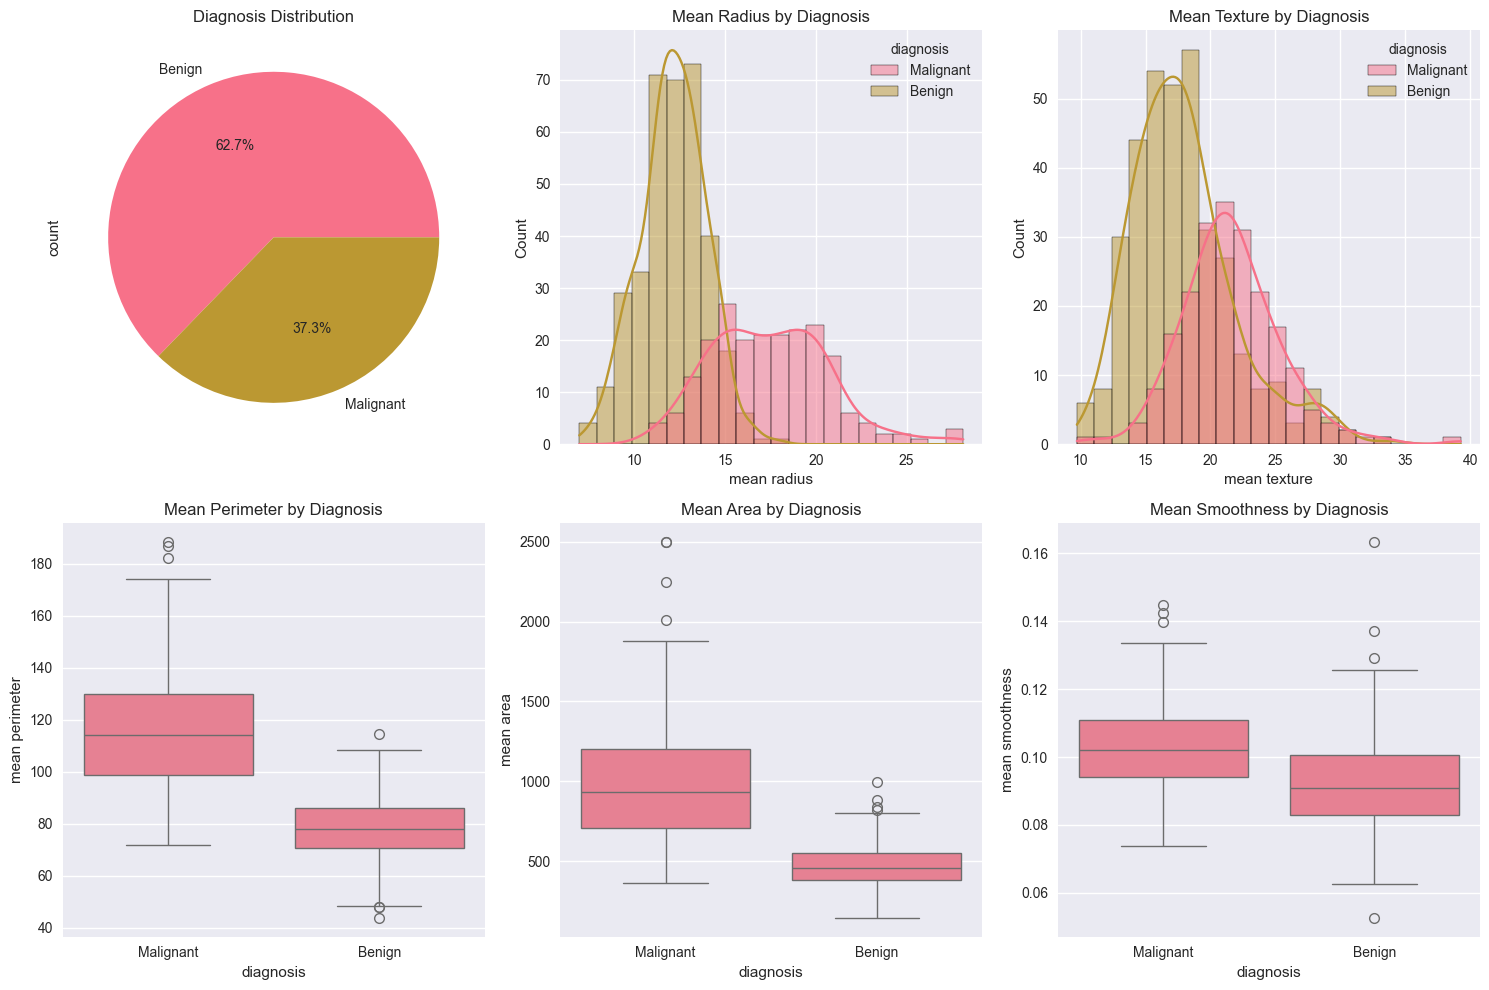

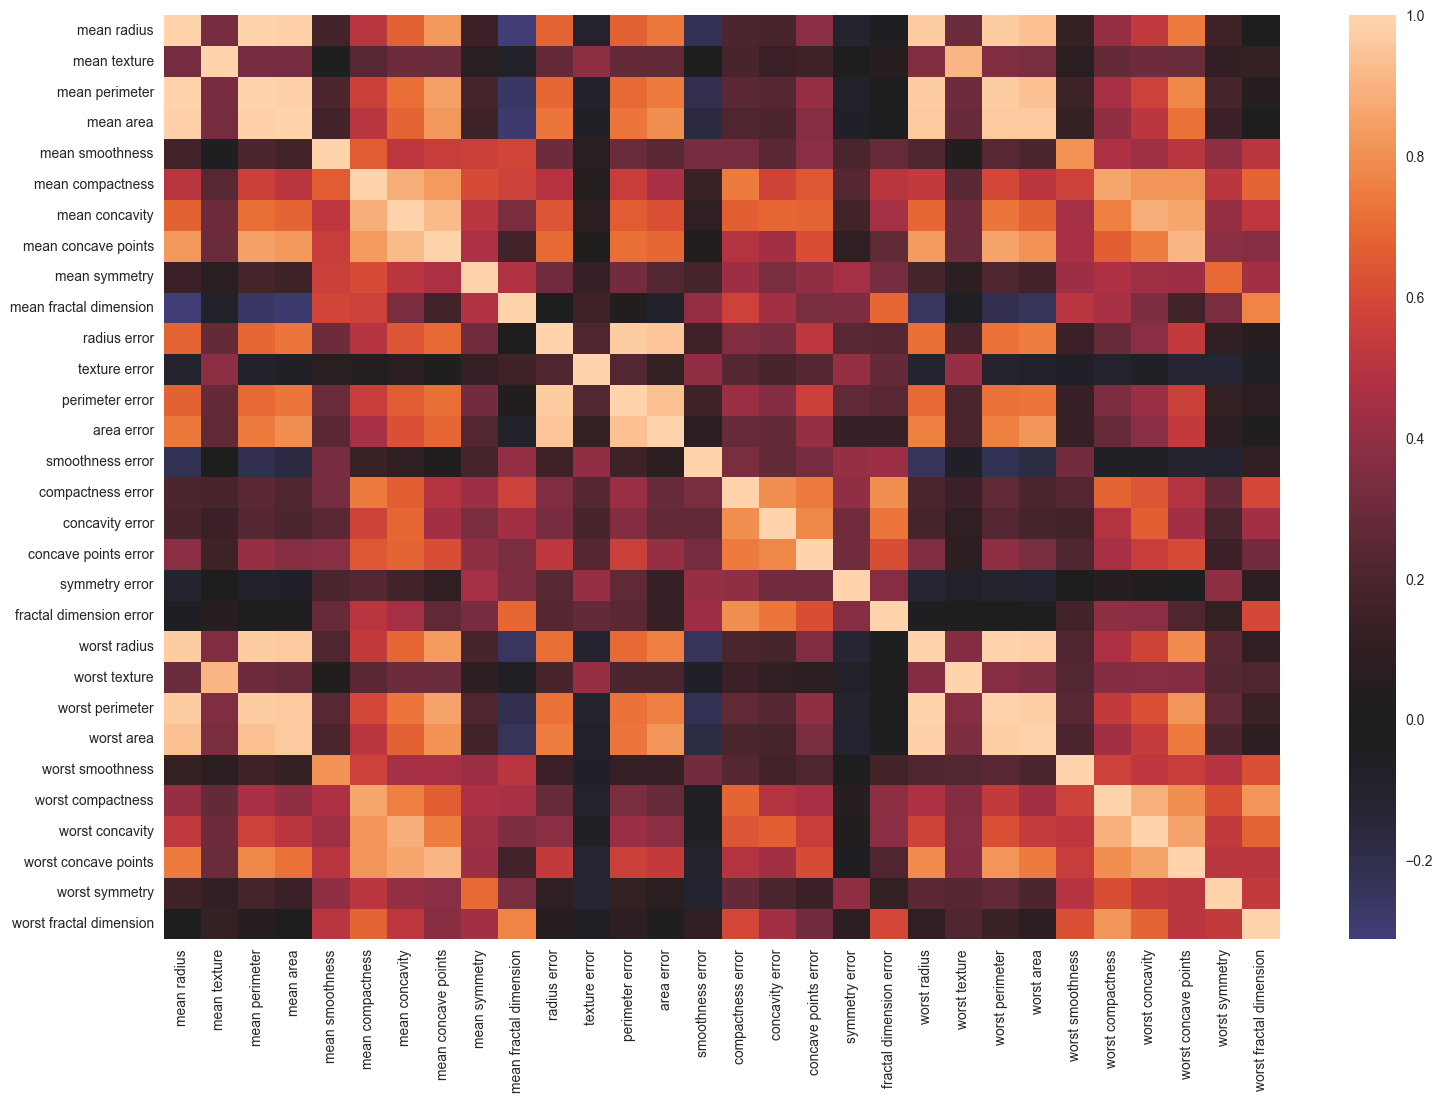

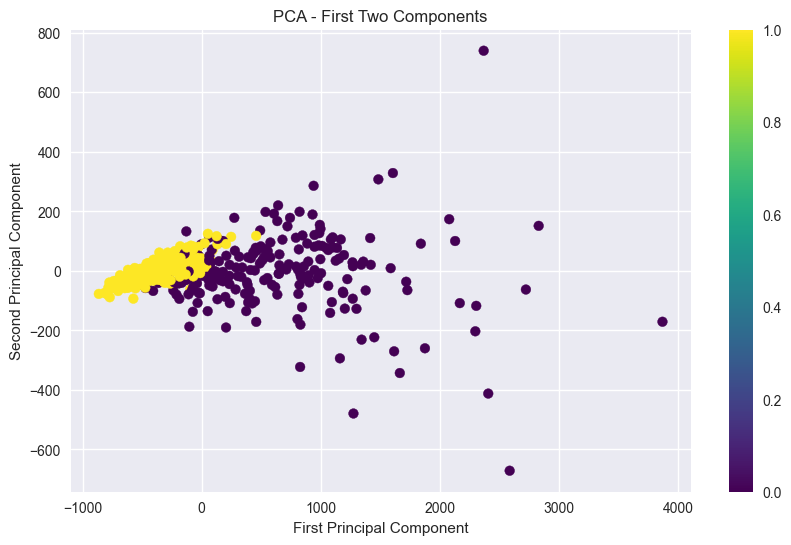

In [23]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
df['diagnosis'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Diagnosis Distribution')

plt.subplot(2, 3, 2)
sns.histplot(data=df, x='mean radius', hue='diagnosis', kde=True)
plt.title('Mean Radius by Diagnosis')

plt.subplot(2, 3, 3)
sns.histplot(data=df, x='mean texture', hue='diagnosis', kde=True)
plt.title('Mean Texture by Diagnosis')

plt.subplot(2, 3, 4)
sns.boxplot(data=df, x='diagnosis', y='mean perimeter')
plt.title('Mean Perimeter by Diagnosis')

plt.subplot(2, 3, 5)
sns.boxplot(data=df, x='diagnosis', y='mean area')
plt.title('Mean Area by Diagnosis')

plt.subplot(2, 3, 6)
sns.boxplot(data=df, x='diagnosis', y='mean smoothness')
plt.title('Mean Smoothness by Diagnosis')

plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
sns.heatmap(df.drop(['target', 'diagnosis'], axis=1).corr(), center=0, fmt='g')
plt.show()

plt.figure(figsize=(10, 6))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df.drop(['target', 'diagnosis'], axis=1))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['target'], cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA - First Two Components')
plt.colorbar()
plt.show()

In [24]:
X = df.drop(['target', 'diagnosis'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
results = {}

for kernel in kernels:
  print(f"Kernel {kernel}")
  svm = SVC(kernel=kernel, random_state=42)
  svm.fit(X_train_scaled, y_train)
  y_pred = svm.predict(X_test_scaled)
  acc = accuracy_score(y_test, y_pred)
  results[kernel] = acc
  print(f"{kernel} accuracy: {acc:.4f}")

Kernel linear
linear accuracy: 0.9737
Kernel poly
poly accuracy: 0.9123
Kernel rbf
rbf accuracy: 0.9825
Kernel sigmoid
sigmoid accuracy: 0.9298


In [27]:
param_grid = {
  'C': [0.1, 1, 10, 100],
  'gamma': [1, 0.1, 0.01, 0.001],
  'kernel': ['rbf', 'linear', 'poly']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, refit=True, cv=5, scoring='accuracy')
grid.fit(X_train_scaled, y_train)

print(f"Best params: {grid.best_params_}")
print(f"Best score : {grid.best_score_:.4f}")

best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)
best_acc = accuracy_score(y_test, y_pred_best)
print(f"Test accuracy with best params: {best_acc:.4f}")

print("Default RBF kernel vs Tuned SVM:")
default_rbf = SVC(kernel='rbf', random_state=42)
default_rbf.fit(X_train_scaled, y_train)
y_pred_default = default_rbf.predict(X_test_scaled)
default_accuracy = accuracy_score(y_test, y_pred_default)

print(f"Default RBF accuracy: {default_accuracy:.4f}")
improvement = best_acc - default_accuracy
print(f"Improvement: {improvement:.4f}")

Best params: {'C': 0.1, 'gamma': 1, 'kernel': 'linear'}
Best score : 0.9802
Test accuracy with best params: 0.9825
Default RBF kernel vs Tuned SVM:
Default RBF accuracy: 0.9825
Improvement: 0.0000


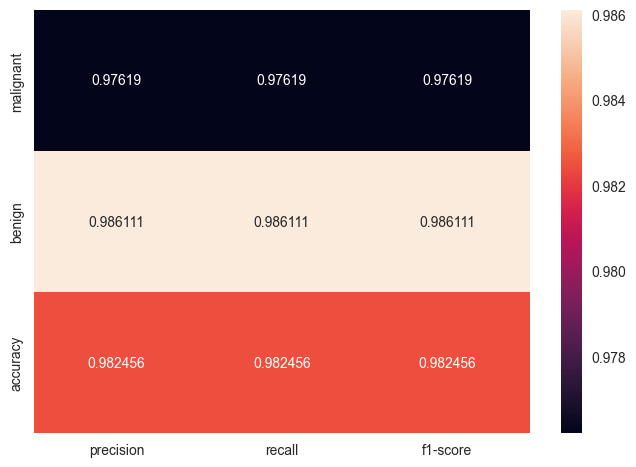

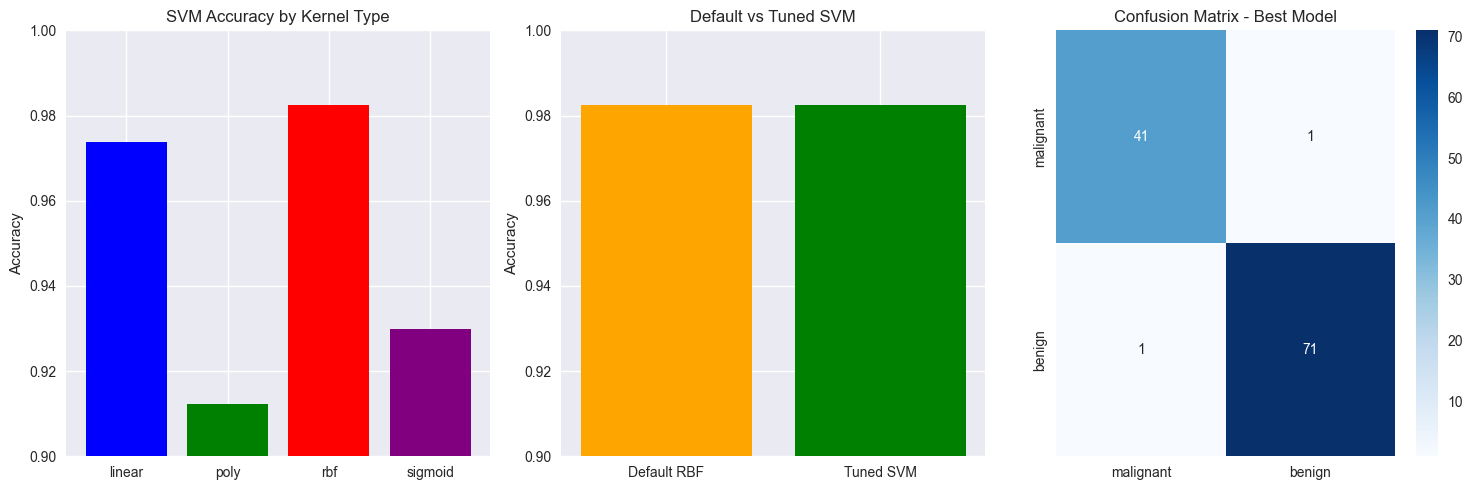

In [30]:
sns.heatmap(pd.DataFrame(classification_report(y_test, y_pred_best, target_names=target_names, output_dict=True)).T.iloc[0:3, 0:3], annot=True, fmt='g')

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
kernel_names = list(results.keys())
accs = list(results.values())
plt.bar(kernel_names, accs, color=['blue', 'green', 'red', 'purple'])
plt.title('SVM Accuracy by Kernel Type')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)

plt.subplot(1, 3, 2)
labels = ['Default RBF', 'Tuned SVM']
plt.bar(labels, [default_accuracy, best_acc], color=['orange', 'green'])
plt.title('Default vs Tuned SVM')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0)

plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Best Model')

plt.tight_layout()
plt.show()

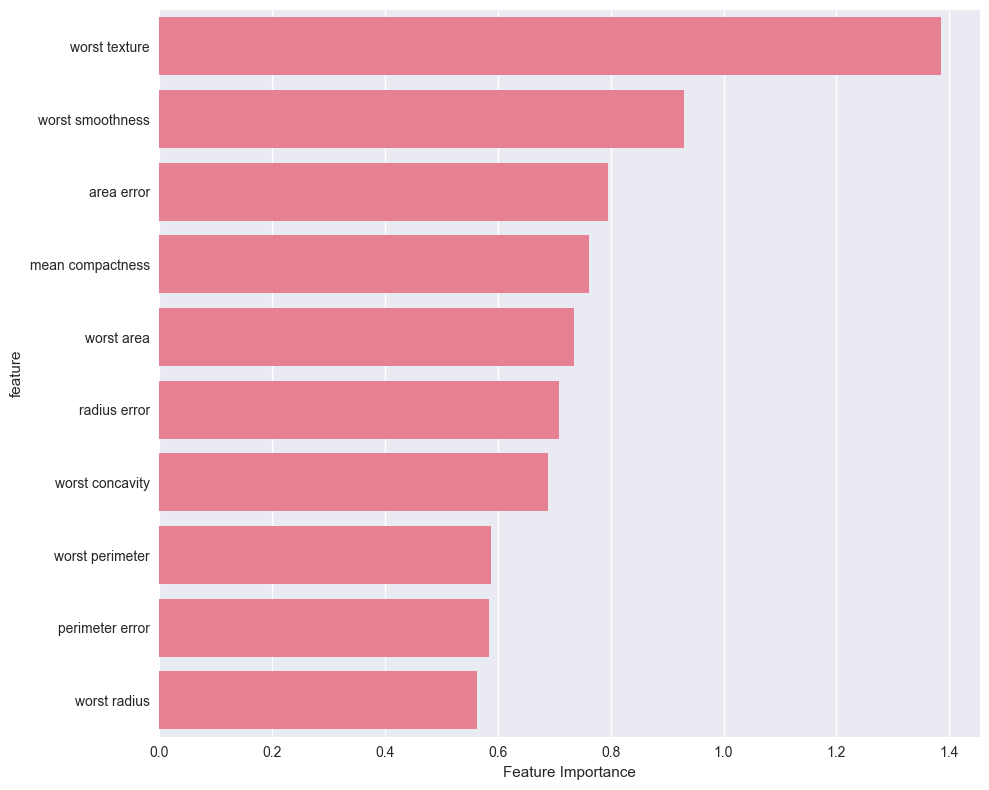

,feature,importance
21,worst texture,1.385227
24,worst smoothness,0.929309
13,area error,0.794588
5,mean compactness,0.761259
23,worst area,0.734185
10,radius error,0.708771
26,worst concavity,0.688305
22,worst perimeter,0.587179
12,perimeter error,0.584898
20,worst radius,0.562414


In [31]:
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)
linear_svm.fit(X_train_scaled, y_train)

feature_imp = pd.DataFrame({
  'feature': feature_names,
  'importance': abs(linear_svm.coef_[0])
})
feature_imp = feature_imp.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_imp.head(10), x='importance', y='feature')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

display(feature_imp.head(10))

In [32]:
print(f"Best kernel: {grid.best_params_['kernel']}")
print(f"Best C: {grid.best_params_['C']}")
print(f"Best gamma: {grid.best_params_['gamma']}")
print(f"Final test accuracy: {best_acc:.4f}")
print("EDA and SVM analysis completed.")

Best kernel: linear
Best C: 0.1
Best gamma: 1
Final test accuracy: 0.9825
EDA and SVM analysis completed.
